In [4]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from xgboost import XGBRegressor,plot_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, root_mean_squared_error

In [5]:
# Importing Dataset
df = pd.read_csv('https://raw.githubusercontent.com/MohammedAyanSyed/projects/refs/heads/main/sklearn-ml-projects/cloud_pricing/cloud_pricing.csv')

In [6]:
# Info of Dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   provider         200000 non-null  object 
 1   region           200000 non-null  object 
 2   instance_type    200000 non-null  object 
 3   vCPU             200000 non-null  int64  
 4   ram_gb           200000 non-null  int64  
 5   storage_gb       200000 non-null  int64  
 6   bandwidth_tb     200000 non-null  float64
 7   contract_type    200000 non-null  object 
 8   usage_hours      200000 non-null  int64  
 9   monthly_cost($)  200000 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 15.3+ MB


,vCPU,ram_gb,storage_gb,bandwidth_tb,usage_hours,monthly_cost($)
count,200000.000000,200000.00000,200000.000000,200000.00000,200000.000000,200000.000000
mean,6.203780,24.80968,450.666000,2.74575,575.854200,115.620624
std,4.687164,18.74592,350.067092,1.29660,176.393401,47.652937
min,2.000000,8.00000,100.000000,0.50000,360.000000,24.140000
25%,2.000000,8.00000,200.000000,1.63000,360.000000,79.720000
50%,4.000000,16.00000,500.000000,2.74000,720.000000,107.440000
75%,8.000000,32.00000,1000.000000,3.87000,720.000000,144.120000
max,16.000000,64.00000,1000.000000,5.00000,720.000000,314.490000


In [5]:
# Null Check
df.isnull().sum()

,0
provider,0
region,0
instance_type,0
vCPU,0
ram_gb,0
storage_gb,0
bandwidth_tb,0
contract_type,0
usage_hours,0
monthly_cost($),0


In [7]:
# Feature Engineering
compute = df['vCPU']+df['ram_gb']
df.insert(5,'Compute',compute)

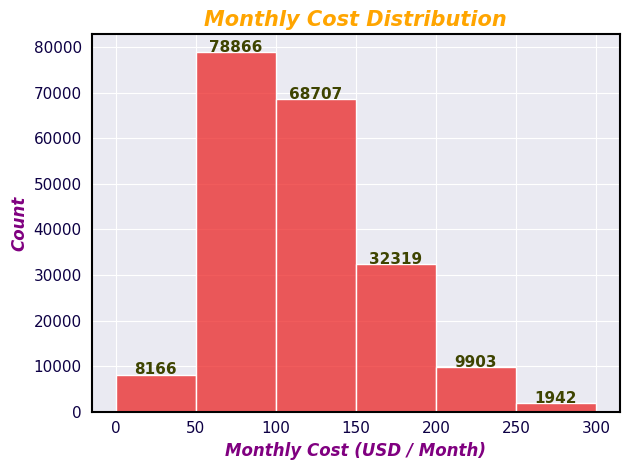

In [8]:
# Page Theme
sns.set_style('darkgrid')

# Histplot
b = [0,50,100,150,200,250,300]
ax = sns.histplot(x='monthly_cost($)',data=df,color='#EB2626',bins=b)

# Annotation
for i in ax.patches:
    height = i.get_height()
    if height>0:
        plt.text(i.get_x()+i.get_width()/2,height+1000,height,ha='center',va='center',fontweight='bold',color='#3e4400',
                 fontsize=11)

# Styling Title and Labels
plt.title('Monthly Cost Distribution',color='Orange',fontweight='bold',fontstyle='oblique',fontsize=15)
plt.xlabel('Monthly Cost (USD / Month)',color='purple',fontweight='bold',fontstyle='oblique',fontsize=12)
plt.ylabel('Count',color='purple',fontweight='bold',fontstyle='oblique',fontsize=12)
for spine in ax.spines.values():
    spine.set_color('k')
    spine.set_linewidth(1.5)
plt.tick_params(axis='both',labelcolor='#0d0044',labelsize=11)

# Page Layout
plt.tight_layout()
plt.show()

# Insights :
# Most cloud instances fall in low–to–mid cost range, with right-skewed distribution,
# indicates a small number of high-cost workloads.

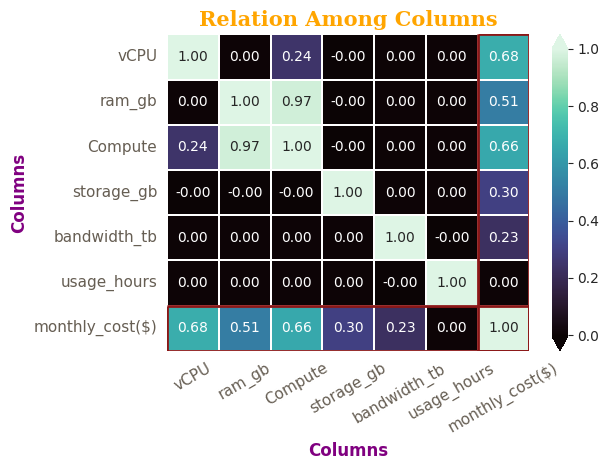

In [9]:
# Feature Relation
cols = df.select_dtypes(['int64','float64']).columns.to_list()
relation = df[cols].corr()

# Heatmap
c = {'shrink':1,'extend':'both'}
ax = sns.heatmap(relation,annot=True,fmt='.2f',cmap='mako',linewidth=0.2,cbar_kws=c)

# Annotation
ax.hlines(y=[0,7],xmin=6,xmax=7,color='#8b1717',linewidth=2)
ax.vlines(x=[6,7],ymin=0,ymax=7,color='#8b1717',linewidth=2)
ax.hlines(y=[6,7],xmin=0,xmax=7,color='#8b1717',linewidth=2)
ax.vlines(x=[0,7],ymin=6,ymax=7,color='#8b1717',linewidth=2)

# Styling Title and Labels
plt.title('Relation Among Columns',color='Orange',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Columns',color='purple',fontweight='bold',fontsize=12)
plt.ylabel('Columns',color='purple',fontweight='bold',fontsize=12)
plt.xticks(rotation=30)
plt.tick_params(axis='both',labelcolor='#665e53',labelsize=11)

# Page Layout
plt.tight_layout()
plt.show()

# Insights :
# vCPU and RAM show strong positive correlation with monthly_cost,
# confirming that compute resources are primary cost drivers.

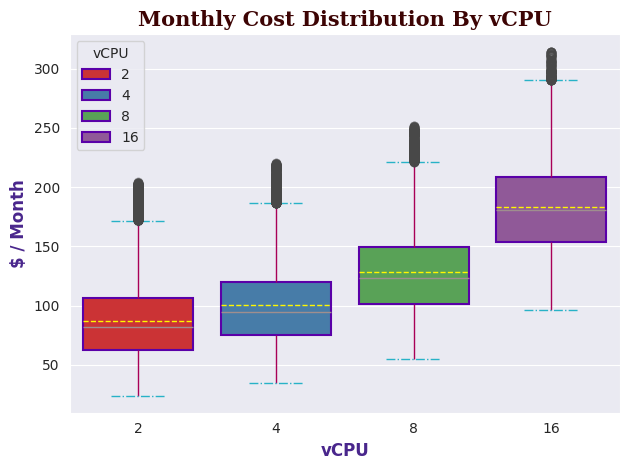

In [10]:
# Page theme
sns.set_style('darkgrid')

# Boxplot
b = {'edgecolor':'#5A00A8','linewidth':1.5}
c = {'color':'#28B2C7','linestyle':'-.'}
w = {'color':'#A80057'}
m = {'color':'#FFF700'}
md = {'color':'#9F8E8E'}
f = {'marker':'o','alpha':0.3}
sns.boxplot(x='vCPU',y='monthly_cost($)',data=df,hue='vCPU',palette='Set1',showmeans=True,meanline=True,boxprops=b,capprops=c,whiskerprops=w,
           meanprops=m,medianprops=md,flierprops=f)

# Styling Title and Labels
plt.title('Monthly Cost Distribution By vCPU',color='#3D0404',fontsize=15,fontfamily='Serif',fontweight='bold')
plt.xlabel('vCPU',fontsize=12,color='#49268C',fontweight='bold')
plt.ylabel('$ / Month',fontsize=12,color='#49268C',fontweight='bold')

# Page Layout
plt.tight_layout()
plt.show()

# Insight
# As vCPU increases, both median cost and cost distribution increase,
# showing that higher compute lead to less predictable and higher expenses

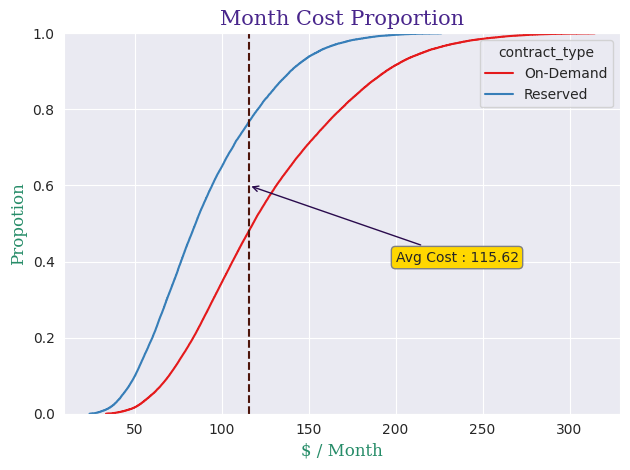

In [11]:
sns.set_style('darkgrid')
sns.ecdfplot(x='monthly_cost($)',data=df,hue='contract_type',palette='Set1')

# Annotation
mean_val = df['monthly_cost($)'].mean()
plt.axvline(mean_val,linestyle='--',color='#4D150B')
plt.annotate(f'Avg Cost : {round(mean_val,2)}',xy=(mean_val,0.6),xytext=(200,0.4),arrowprops=dict(color='#2A0B4D',arrowstyle='->'),
            bbox=dict(facecolor='gold',boxstyle='round',edgecolor='grey'))
# Styling Title and Labels
plt.title('Month Cost Proportion',fontsize=15,fontfamily='Serif',color='#49268C')
plt.xlabel('$ / Month',fontsize=12,fontfamily='Serif',color='#268C68')
plt.ylabel('Propotion',fontsize=12,fontfamily='Serif',color='#268C68')

# Page Layout
plt.tight_layout()
plt.show()
# Insight
# A larger number of instances using Reserved contracts stay within lower monthly cost ranges compared to On-Demand instances.

In [65]:
# Train Test Split
independent = df.drop('monthly_cost($)',axis=1)
dependent = df['monthly_cost($)']
Xtrain,Xtest,ytrain,ytest = train_test_split(independent,dependent,train_size=0.8)

# Column Transformer
o_cols = Xtrain.select_dtypes('object').columns.to_list()
n_cols = Xtrain.select_dtypes(exclude='object').columns.to_list()
prep = ColumnTransformer([('encode',OneHotEncoder(),o_cols),('scaling',StandardScaler(),n_cols)])

# Pipeline
pipe = Pipeline([('prep',prep),('xbr',XGBRegressor())])

# Parameters
para = {
    'xbr__learning_rate':[0.01,0.1,0.05],
    'xbr__max_depth':[x for x in range(4,13)],
    'xbr__gamma':[0.5,1],
    'xbr__lambda':[x for x in range(1,6)],
    'xbr__alpha':[x for x in range(1,6)],
    'xbr__subsample':[0.7,0.8],
    'xbr__colsample_bytree':[0.7,0.8],
    'xbr__min_child_weight':[x for x in range(4,10)],
    'xbr__eval_metric':['rmse']
}

# Fitting Model
model = RandomizedSearchCV(pipe,para,cv=5,n_iter=50,verbose=2,n_jobs=-1)
model.fit(Xtrain,ytrain)


# Prediction
pred = model.predict(Xtest)
score = r2_score(ytest,pred)
rmse = root_mean_squared_error(ytest,pred)
print(f'R2_score = {score} and RMSE score = {rmse} Best Parameters = {model.best_params_}')

# Model Insights

# Important Features :
# vCPU, RAM, and Compute mostly decide the monthly cloud cost.
# The model gave high importance to these features, which makes sense because more CPU/RAM costs more.

# Contract type and usage hours:
# These features don’t affect the price much.
# XGBoost ignored them mostly, so we know pricing depends more on hardware than usage.

# Feature engineering helps:
# Adding the Compute feature (vCPU + RAM) improved model performance a bit.
# Shows that combining related features can help predict price better.

# Conclusion:
# The model can predict monthly cost pretty well using hardware specs.
# It’s a good start for making a cost prediction tool.

Fitting 5 folds for each of 50 candidates, totalling 250 fits
R2_score = 0.9999488469520235 and RMSE score = 0.34108063300993113 Best Parameters = {'xbr__subsample': 0.7, 'xbr__min_child_weight': 5, 'xbr__max_depth': 12, 'xbr__learning_rate': 0.1, 'xbr__lambda': 2, 'xbr__gamma': 0.5, 'xbr__eval_metric': 'rmse', 'xbr__colsample_bytree': 0.8, 'xbr__alpha': 2}


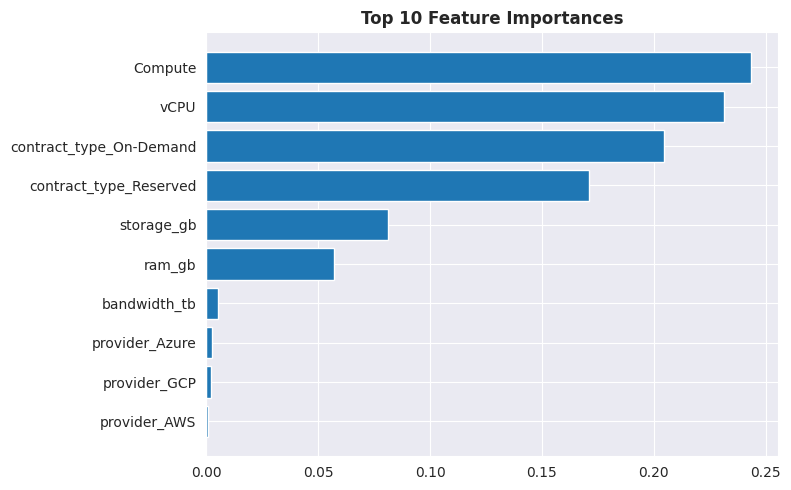

In [66]:
# Feature Importances plot

# Feature Names
best_mod = model.best_estimator_
prep_fit = best_mod.named_steps['prep']
c_cols = prep_fit.named_transformers_['encode'].get_feature_names_out()
f_names = list(c_cols)+list(n_cols)

# Dataframe
step = best_mod.named_steps['xbr']
importance = step.feature_importances_
fe_importances = pd.DataFrame(
    {'Feature':f_names,'Importances':importance}
    ).sort_values(by='Importances',ascending=0).head(10)

# Bar Plot
plt.figure(figsize=(8,5))
sns.set_style('darkgrid')
plt.barh('Feature','Importances',data=fe_importances)
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances',fontweight='bold')
plt.tight_layout()
plt.show()

In [67]:
# Saving Model
import joblib
joblib.dump(model,'cloud_price_prediction')

['cloud_price_prediction']